## Поиск точки начального приближения


Поиск оптимального начального приближения для системы уравнений:
f1(x1,x2) = cos(x2 - 2) + x1 = 0
f2(x1,x2) = sin(x1 + 0.5) - x2 - 1.2 = 0


Поиск в диапазоне x1: (-1, 1), x2: (-1, 1)

Найденные кандидаты:
Кандидат 1: x1 = 0.7778, x2 = -0.3333, невязка = 0.1257, обусловленность = 1.4806
Кандидат 2: x1 = 0.5556, x2 = -0.3333, невязка = 0.1352, обусловленность = 1.2183
Кандидат 3: x1 = 0.5556, x2 = -0.1111, невязка = 0.2226, обусловленность = 1.3562
Кандидат 4: x1 = 0.7778, x2 = -0.1111, невязка = 0.2944, обусловленность = 1.6550
Кандидат 5: x1 = 0.7778, x2 = -0.5556, невязка = 0.3178, обусловленность = 1.2773


<ipython-input-9-4f69b8f01bd0>:154: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
<ipython-input-9-4f69b8f01bd0>:155: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')


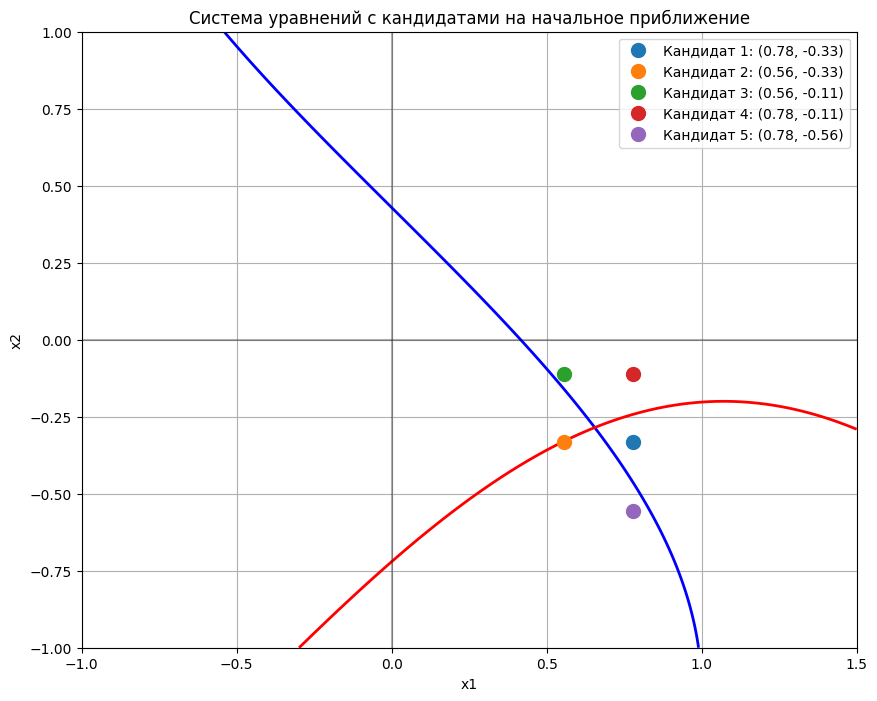

<ipython-input-9-4f69b8f01bd0>:180: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
<ipython-input-9-4f69b8f01bd0>:181: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')


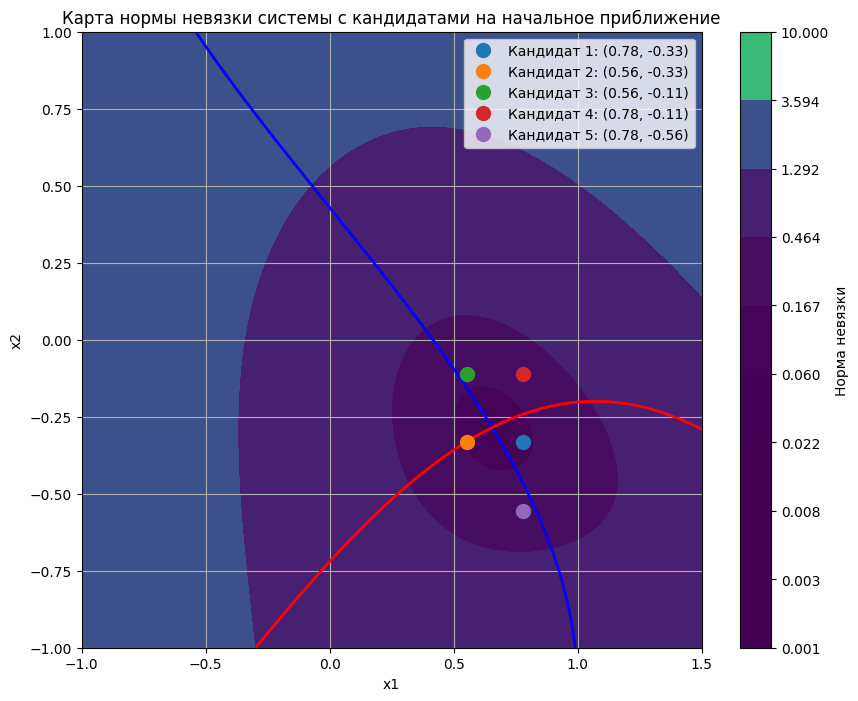


Анализ кандидатов для начального приближения:
№  x0          Невязка   Обусл.    Ньютон сх.Итераций  Прост.ит. сх.Итераций  
------------------------------------------------------------------------------
1  (0.78, -0.33)0.1257    1.4806    Да        4         Да           17        
2  (0.56, -0.33)0.1352    1.2183    Да        3         Да           18        
3  (0.56, -0.11)0.2226    1.3562    Да        4         Да           19        
4  (0.78, -0.11)0.2944    1.6550    Да        4         Да           19        
5  (0.78, -0.56)0.3178    1.2773    Да        4         Да           19        

Рекомендуемое начальное приближение: кандидат 1 с координатами (0.7778, -0.3333)
Этот кандидат обеспечивает сходимость обоих методов за минимальное число итераций.

Итоговое рекомендуемое начальное приближение: (0.7778, -0.3333)

Код для использования найденного оптимального начального приближения:
x0 = [0.7777777777777777, -0.33333333333333337]  # Оптимальное начальное приближение


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def f1(x1, x2):
    """Первая функция системы: cos(x2 - 2) + x1 = 0"""
    return np.cos(x2 - 2) + x1

def f2(x1, x2):
    """Вторая функция системы: sin(x1 + 0.5) - x2 - 1.2 = 0"""
    return np.sin(x1 + 0.5) - x2 - 1.2

def jacob(x1, x2):
    """Матрица Якоби для системы"""
    j11 = 1
    j12 = -np.sin(x2 - 2)
    j21 = np.cos(x1 + 0.5)
    j22 = -1
    return np.array([[j11, j12], [j21, j22]])

def residual_norm(x1, x2):
    """Норма невязки (норма вектора значений функций)"""
    return np.sqrt(f1(x1, x2)**2 + f2(x1, x2)**2)

def jacob_cond(x1, x2):
    """Число обусловленности матрицы Якоби"""
    j = jacob(x1, x2)
    try:
        return np.linalg.cond(j)
    except:
        return np.inf

def find_candidate_points(n=10, x1_range=(-1, 1), x2_range=(-1, 1)):
    """Поиск кандидатов на хорошие начальные приближения"""
    # Создаем сетку точек
    x1_points = np.linspace(x1_range[0], x1_range[1], n)
    x2_points = np.linspace(x2_range[0], x2_range[1], n)
    X1, X2 = np.meshgrid(x1_points, x2_points)

    # Вычисляем значения функций на сетке
    F1 = np.zeros_like(X1)
    F2 = np.zeros_like(X2)
    RES = np.zeros_like(X1)
    COND = np.zeros_like(X1)

    for i in range(n):
        for j in range(n):
            x1, x2 = X1[i, j], X2[i, j]
            F1[i, j] = f1(x1, x2)
            F2[i, j] = f2(x1, x2)
            RES[i, j] = residual_norm(x1, x2)
            COND[i, j] = jacob_cond(x1, x2)

    # Анализируем точки с наименьшей нормой невязки и хорошей обусловленностью
    candidates = []
    for i in range(n):
        for j in range(n):
            candidates.append({
                'x1': X1[i, j],
                'x2': X2[i, j],
                'f1': F1[i, j],
                'f2': F2[i, j],
                'residual': RES[i, j],
                'cond': COND[i, j]
            })

    # Сортируем кандидатов по норме невязки
    candidates.sort(key=lambda x: x['residual'])

    return candidates[:5]  # Возвращаем 5 лучших кандидатов

def newton_test(x0, eps=1e-5, max_iter=20):
    """Тестирование сходимости метода Ньютона"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        x1, x2 = x
        f = np.array([f1(x1, x2), f2(x1, x2)])
        error = np.linalg.norm(f)

        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error': error
        })

        if error < eps:
            return True, iterations

        j = jacob(x1, x2)
        try:
            delta = np.linalg.solve(j, -f)
        except np.linalg.LinAlgError:
            return False, iterations

        x = x + delta

    # Если достигли максимального числа итераций без сходимости
    return n + 1 < max_iter, iterations

def simple_iteration_test(x0, eps=1e-5, max_iter=20):
    """Тестирование сходимости метода простых итераций"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        x1, x2 = x

        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error': np.linalg.norm([f1(x1, x2), f2(x1, x2)])
        })

        if np.linalg.norm([f1(x1, x2), f2(x1, x2)]) < eps:
            return True, iterations

        if n > 0 and np.linalg.norm(x - x_prev) < eps:
            return True, iterations

        x_prev = x.copy()

        # Вычисляем новое приближение
        x = np.array([
            -np.cos(x2 - 2),
            np.sin(x1 + 0.5) - 1.2
        ])

        # Проверка на расходимость (если значения стали слишком большими)
        if np.any(np.abs(x) > 100):
            return False, iterations

    # Если достигли максимального числа итераций без сходимости
    return n + 1 < max_iter, iterations

def plot_system_with_candidates(candidates):
    """Визуализация системы с кандидатами на начальное приближение"""
    # Создание сетки точек для построения графиков
    x1 = np.linspace(-1, 1.5, 300)
    x2 = np.linspace(-1, 1, 300)
    X1, X2 = np.meshgrid(x1, x2)

    # Вычисление значений функций на сетке
    Z1 = f1(X1, X2)
    Z2 = f2(X1, X2)

    plt.figure(figsize=(10, 8))

    # График обеих функций
    plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
    plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')

    # Отмечаем кандидатов на начальное приближение
    for i, c in enumerate(candidates):
        plt.plot(c['x1'], c['x2'], 'o', markersize=10, label=f"Кандидат {i+1}: ({c['x1']:.2f}, {c['x2']:.2f})")

    plt.grid(True)
    plt.title('Система уравнений с кандидатами на начальное приближение')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.xlim(-1, 1.5)
    plt.ylim(-1, 1)
    plt.show()

    # График нормы невязки
    plt.figure(figsize=(10, 8))
    RES = np.sqrt(Z1**2 + Z2**2)
    levels = np.logspace(-3, 1, 10)
    contour = plt.contourf(X1, X2, RES, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Норма невязки')

    # Отмечаем линии, где функции равны нулю
    plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
    plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')

    # Отмечаем кандидатов
    for i, c in enumerate(candidates):
        plt.plot(c['x1'], c['x2'], 'o', markersize=10, label=f"Кандидат {i+1}: ({c['x1']:.2f}, {c['x2']:.2f})")

    plt.grid(True)
    plt.title('Карта нормы невязки системы с кандидатами на начальное приближение')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.xlim(-1, 1.5)
    plt.ylim(-1, 1)
    plt.show()

def analyze_candidates(candidates):
    """Анализ кандидатов для обоих методов"""
    results = []

    for i, c in enumerate(candidates):
        x0 = [c['x1'], c['x2']]

        # Тестируем метод Ньютона
        newton_converged, newton_iterations = newton_test(x0)
        newton_iters = len(newton_iterations)

        # Тестируем метод простых итераций
        simple_converged, simple_iterations = simple_iteration_test(x0)
        simple_iters = len(simple_iterations)

        results.append({
            'candidate': i + 1,
            'x0': x0,
            'residual': c['residual'],
            'cond': c['cond'],
            'newton_converged': newton_converged,
            'newton_iters': newton_iters,
            'simple_converged': simple_converged,
            'simple_iters': simple_iters
        })

    # Выводим результаты в виде таблицы
    print("\nАнализ кандидатов для начального приближения:")
    headers = ["№", "x0", "Невязка", "Обусл.", "Ньютон сх.", "Итераций", "Прост.ит. сх.", "Итераций"]

    # Формируем строки таблицы
    rows = []
    for r in results:
        rows.append([
            r['candidate'],
            f"({r['x0'][0]:.2f}, {r['x0'][1]:.2f})",
            f"{r['residual']:.4f}",
            f"{r['cond']:.4f}",
            "Да" if r['newton_converged'] else "Нет",
            r['newton_iters'],
            "Да" if r['simple_converged'] else "Нет",
            r['simple_iters']
        ])

    # Печатаем таблицу
    col_widths = [3, 12, 10, 10, 10, 10, 13, 10]
    # Заголовок
    header_str = ""
    for i, h in enumerate(headers):
        header_str += h.ljust(col_widths[i])
    print(header_str)
    print("-" * sum(col_widths))

    # Строки
    for row in rows:
        row_str = ""
        for i, cell in enumerate(row):
            row_str += str(cell).ljust(col_widths[i])
        print(row_str)

    # Определяем лучшего кандидата
    best_candidates = []
    for r in results:
        if r['newton_converged'] and r['simple_converged']:
            score = r['newton_iters'] + r['simple_iters']  # Меньше итераций - лучше
            best_candidates.append((r['candidate'], score, r['x0']))

    if best_candidates:
        best_candidates.sort(key=lambda x: x[1])  # Сортировка по сумме итераций (меньше лучше)
        best = best_candidates[0]
        print(f"\nРекомендуемое начальное приближение: кандидат {best[0]} с координатами ({best[2][0]:.4f}, {best[2][1]:.4f})")
        print(f"Этот кандидат обеспечивает сходимость обоих методов за минимальное число итераций.")
        return best[2]
    else:
        print("\nНе найдено подходящего начального приближения, обеспечивающего сходимость обоих методов.")
        # Находим лучшего кандидата хотя бы для метода Ньютона
        newton_candidates = []
        for r in results:
            if r['newton_converged']:
                newton_candidates.append((r['candidate'], r['newton_iters'], r['x0']))

        if newton_candidates:
            newton_candidates.sort(key=lambda x: x[1])
            best_newton = newton_candidates[0]
            print(f"Рекомендуемое начальное приближение для метода Ньютона: кандидат {best_newton[0]} с координатами ({best_newton[2][0]:.4f}, {best_newton[2][1]:.4f})")
            return best_newton[2]
        else:
            print("Не найдено подходящего начального приближения даже для метода Ньютона.")
            return None

def search_optimal_initial_point():
    """Поиск оптимального начального приближения"""
    print("\nПоиск оптимального начального приближения для системы уравнений:")
    print("f1(x1,x2) = cos(x2 - 2) + x1 = 0")
    print("f2(x1,x2) = sin(x1 + 0.5) - x2 - 1.2 = 0\n")

    # Поиск в более широком диапазоне
    search_ranges = [
        ((-1, 1), (-1, 1)),  # Начальный диапазон
        ((0, 1), (-1, 0)),   # Уточненный диапазон, ближе к решению
        ((0.5, 0.7), (-0.4, -0.2))  # Очень узкий диапазон вокруг предполагаемого решения
    ]

    best_point = None

    for x1_range, x2_range in search_ranges:
        print(f"\nПоиск в диапазоне x1: {x1_range}, x2: {x2_range}")
        candidates = find_candidate_points(n=10, x1_range=x1_range, x2_range=x2_range)

        # Вывод списка кандидатов
        print("\nНайденные кандидаты:")
        for i, c in enumerate(candidates):
            print(f"Кандидат {i+1}: x1 = {c['x1']:.4f}, x2 = {c['x2']:.4f}, невязка = {c['residual']:.4f}, обусловленность = {c['cond']:.4f}")

        # Визуализация кандидатов
        plot_system_with_candidates(candidates)

        # Анализ кандидатов
        point = analyze_candidates(candidates)
        if point:
            best_point = point
            break

    if best_point:
        print(f"\nИтоговое рекомендуемое начальное приближение: ({best_point[0]:.4f}, {best_point[1]:.4f})")
        return best_point
    else:
        print("\nНе удалось найти оптимальное начальное приближение.")
        return [0.5, -0.3]  # Возвращаем приближение, близкое к решению

if __name__ == "__main__":
    optimal_point = search_optimal_initial_point()
    print("\nКод для использования найденного оптимального начального приближения:")
    print(f"x0 = [{optimal_point[0]}, {optimal_point[1]}]  # Оптимальное начальное приближение")

## Решение

<ipython-input-10-575a6a90b164>:210: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
<ipython-input-10-575a6a90b164>:211: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')


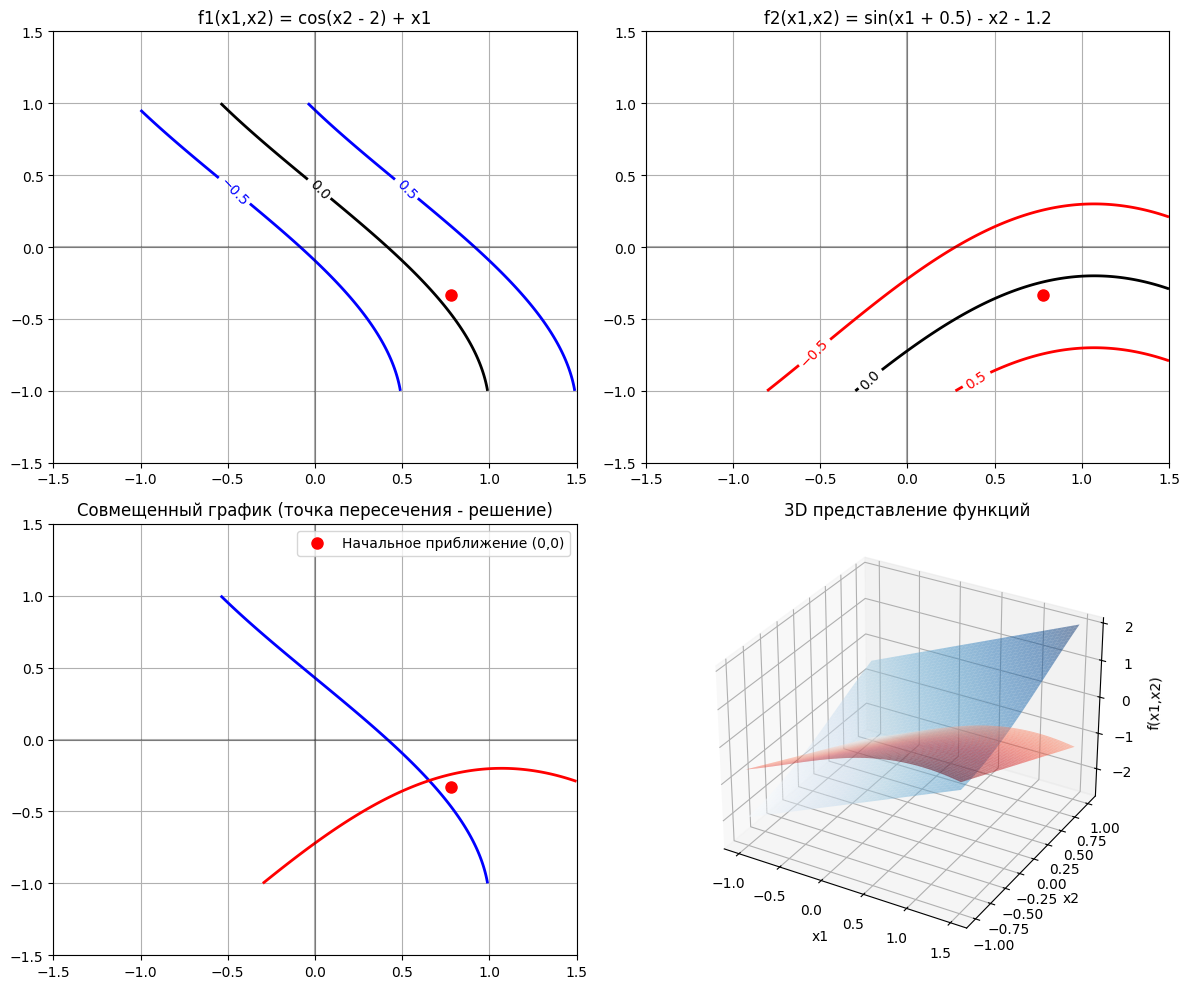

1. Значение f1(0, 0) = 0.091656
2. Значение f2(0, 0) = 0.088016
3. Определитель матрицы Якоби в точке (0,0): -1.207979
Решение методом Ньютона:
+-----+----------+-----------+-----------------+-----------------+
|   n |     x1^n |      x2^n |   ε_f (невязка) |   ε_x (разница) |
+=====+==========+===========+=================+=================+
|   0 | 0.780000 | -0.330000 |        0.127073 |      inf        |
+-----+----------+-----------+-----------------+-----------------+
|   1 | 0.651271 | -0.278893 |        0.007874 |        0.138503 |
+-----+----------+-----------+-----------------+-----------------+
|   2 | 0.655137 | -0.285143 |        0.000014 |        0.007349 |
+-----+----------+-----------+-----------------+-----------------+
|   3 | 0.655131 | -0.285152 |        0.000000 |        0.000011 |
+-----+----------+-----------+-----------------+-----------------+

Проверка решения методом Ньютона:
f1(0.6551308895933861, -0.285152179658894) = 2.754929617765356e-11
f2(0.655130889593

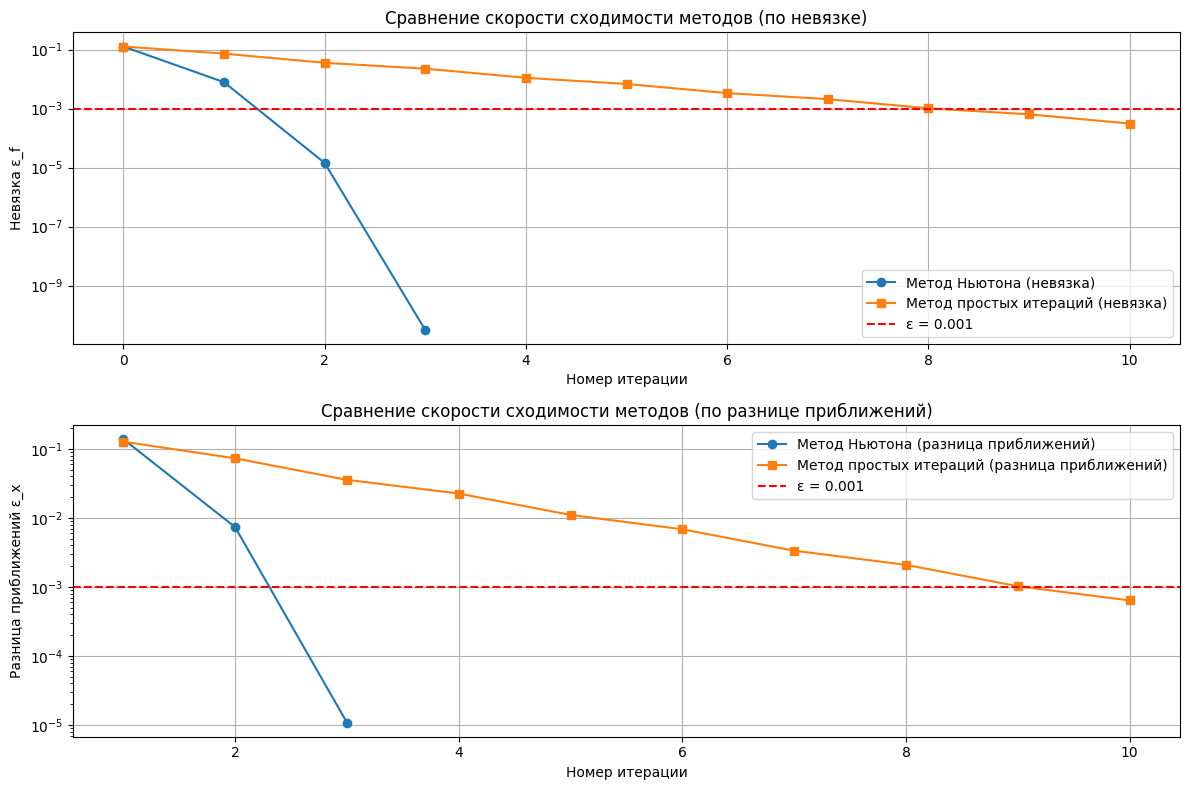


Сравнение методов:
Метод Ньютона: 4 итераций
Метод простых итераций: 11 итераций

Решение методом Ньютона: x1 = 0.655131, x2 = -0.285152
Решение методом простых итераций: x1 = 0.654837, x2 = -0.285039


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

def f1(x1, x2):
    """Первая функция системы: cos(x2 - 2) + x1 = 0"""
    return np.cos(x2 - 2) + x1

def f2(x1, x2):
    """Вторая функция системы: sin(x1 + 0.5) - x2 - 1.2 = 0"""
    return np.sin(x1 + 0.5) - x2 - 1.2

def jacob(x1, x2):
    """Матрица Якоби для системы"""
    j11 = 1
    j12 = -np.sin(x2 - 2)
    j21 = np.cos(x1 + 0.5)
    j22 = -1
    return np.array([[j11, j12], [j21, j22]])

def newton_method(x0, eps=1e-3, max_iter=100):
    """Метод Ньютона для решения системы нелинейных уравнений с дополнительным критерием сходимости"""
    x = np.array(x0, dtype=float)
    iterations = []
    prev_x = None

    for n in range(max_iter):
        # Сохраняем текущее приближение для таблицы
        x1, x2 = x

        # Вычисляем значения функций
        f = np.array([f1(x1, x2), f2(x1, x2)])

        # Вычисляем норму невязки
        error_f = np.linalg.norm(f)

        # Вычисляем разницу между текущим и предыдущим приближением (если возможно)
        error_x = np.inf if prev_x is None else np.linalg.norm(x - prev_x)

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error_f': error_f,
            'error_x': error_x
        })

        # Проверяем условие сходимости:
        # 1. Норма невязки должна быть меньше eps
        # 2. Разница между последовательными приближениями должна быть меньше eps
        if error_f < eps and (prev_x is None or error_x < eps):
            break

        # Сохраняем текущее приближение перед обновлением
        prev_x = x.copy()

        # Вычисляем матрицу Якоби
        j = jacob(x1, x2)

        # Решаем СЛАУ для приращения
        try:
            delta = np.linalg.solve(j, -f)
        except np.linalg.LinAlgError:
            print("Невозможно обратить матрицу Якоби")
            break

        # Обновляем приближение
        x = x + delta

    return x, iterations

def simple_iteration_method(x0, eps=1e-3, max_iter=100):
    """Метод простых итераций для решения системы нелинейных уравнений"""
    x = np.array(x0, dtype=float)
    iterations = []

    for n in range(max_iter):
        # Сохраняем текущее приближение
        x1, x2 = x

        # Вычисляем значения функций для проверки невязки
        error_f = np.linalg.norm([f1(x1, x2), f2(x1, x2)])

        # Вычисляем разницу между текущим и предыдущим приближением (если возможно)
        error_x = 0 if n == 0 else np.linalg.norm(x - x_prev)

        # Сохраняем информацию об итерации
        iterations.append({
            'n': n,
            'x1': x1,
            'x2': x2,
            'error_f': error_f,
            'error_x': error_x
        })

        # Проверка сходимости по разнице последовательных приближений
        if n > 0 and error_x < eps:
            break

        # Сохраняем текущее приближение для сравнения
        x_prev = x.copy()

        # Вычисляем новое приближение
        x = np.array([
            -np.cos(x2 - 2),
            np.sin(x1 + 0.5) - 1.2
        ])

    return x, iterations

def print_iterations_table(iterations):
    """Вывод таблицы итераций с обоими критериями сходимости"""
    table = []
    for it in iterations:
        table.append([
            it['n'],
            it['x1'],
            it['x2'],
            it['error_f'],
            it['error_x'] if 'error_x' in it else 'N/A'
        ])

    headers = ['n', 'x1^n', 'x2^n', 'ε_f (невязка)', 'ε_x (разница)']
    print(tabulate(table, headers=headers, tablefmt='grid', floatfmt='.6f'))

def check_solution(x, method_name):
    """Проверка решения"""
    x1, x2 = x
    print(f"\nПроверка решения методом {method_name}:")
    print(f"f1({x1}, {x2}) = {f1(x1, x2)}")
    print(f"f2({x1}, {x2}) = {f2(x1, x2)}")

def plot_convergence(newton_iterations, simple_iterations):
    """Визуализация скорости сходимости методов"""
    newton_errors_f = [it['error_f'] for it in newton_iterations]
    newton_errors_x = [it['error_x'] for it in newton_iterations if it['n'] > 0]
    simple_errors_f = [it['error_f'] for it in simple_iterations]
    simple_errors_x = [it['error_x'] for it in simple_iterations if it['n'] > 0]

    plt.figure(figsize=(12, 8))

    # График невязок функций
    plt.subplot(2, 1, 1)
    plt.semilogy(range(len(newton_errors_f)), newton_errors_f, 'o-', label='Метод Ньютона (невязка)')
    plt.semilogy(range(len(simple_errors_f)), simple_errors_f, 's-', label='Метод простых итераций (невязка)')
    plt.axhline(y=eps, color='r', linestyle='--', label=f'ε = {eps}')
    plt.xlabel('Номер итерации')
    plt.ylabel('Невязка ε_f')
    plt.grid(True)
    plt.legend()
    plt.title('Сравнение скорости сходимости методов (по невязке)')

    # График разницы приближений
    plt.subplot(2, 1, 2)
    plt.semilogy(range(1, len(newton_errors_x) + 1), newton_errors_x, 'o-', label='Метод Ньютона (разница приближений)')
    plt.semilogy(range(1, len(simple_errors_x) + 1), simple_errors_x, 's-', label='Метод простых итераций (разница приближений)')
    plt.axhline(y=eps, color='r', linestyle='--', label=f'ε = {eps}')
    plt.xlabel('Номер итерации')
    plt.ylabel('Разница приближений ε_x')
    plt.grid(True)
    plt.legend()
    plt.title('Сравнение скорости сходимости методов (по разнице приближений)')

    plt.tight_layout()
    plt.savefig('convergence_comparison.png')
    plt.show()

def plot_functions():
    """Визуализация функций системы уравнений"""
    # Создание сетки точек для построения графиков
    x1 = np.linspace(-1, 1.5, 300)
    x2 = np.linspace(-1, 1, 300)
    X1, X2 = np.meshgrid(x1, x2)

    # Вычисление значений функций на сетке
    Z1 = f1(X1, X2)
    Z2 = f2(X1, X2)

    # Создание графика
    plt.figure(figsize=(12, 10))

    # График первой функции: cos(x2 - 2) + x1 = 0
    plt.subplot(2, 2, 1)
    contour1 = plt.contour(X1, X2, Z1, levels=[-0.5, 0, 0.5], colors=['blue', 'black', 'blue'], linewidths=2)
    plt.clabel(contour1, inline=True, fontsize=10)
    plt.title('f1(x1,x2) = cos(x2 - 2) + x1')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0.78, -0.33, 'ro', markersize=8)  # Начальное приближение
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # График второй функции: sin(x1 + 0.5) - x2 - 1.2 = 0
    plt.subplot(2, 2, 2)
    contour2 = plt.contour(X1, X2, Z2, levels=[-0.5, 0, 0.5], colors=['red', 'black', 'red'], linewidths=2)
    plt.clabel(contour2, inline=True, fontsize=10)
    plt.title('f2(x1,x2) = sin(x1 + 0.5) - x2 - 1.2')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0.78, -0.33, 'ro', markersize=8)  # Начальное приближение
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # Совмещенный график обеих функций
    plt.subplot(2, 2, 3)
    plt.contour(X1, X2, Z1, levels=[0], colors='blue', linewidths=2, label='f1(x1,x2)=0')
    plt.contour(X1, X2, Z2, levels=[0], colors='red', linewidths=2, label='f2(x1,x2)=0')
    plt.title('Совмещенный график (точка пересечения - решение)')
    plt.grid(True)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.plot(0.78, -0.33, 'ro', markersize=8, label='Начальное приближение (0,0)')
    plt.legend()
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)

    # 3D-поверхность для лучшей визуализации
    ax = plt.subplot(2, 2, 4, projection='3d')
    surf1 = ax.plot_surface(X1, X2, Z1, alpha=0.5, cmap='Blues')
    surf2 = ax.plot_surface(X1, X2, Z2, alpha=0.5, cmap='Reds')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('f(x1,x2)')
    ax.set_title('3D представление функций')

    plt.tight_layout()
    plt.savefig('functions_visualization.png')
    plt.show()

def explain_initial_approximation():
    """Анализ выбора начального приближения (0,0)"""
    x0 = [0.78, -0.33]
    x1, x2 = x0

    # Значения функций в точке (0,0)
    f1_val = f1(x1, x2)
    f2_val = f2(x1, x2)

    # Определитель матрицы Якоби в точке (0,0)
    j = jacob(x1, x2)
    det_j = np.linalg.det(j)

    print(f"1. Значение f1(0, 0) = {f1_val:.6f}")
    print(f"2. Значение f2(0, 0) = {f2_val:.6f}")
    print(f"3. Определитель матрицы Якоби в точке (0,0): {det_j:.6f}")


# Начальное приближение
x0 = [0.78, -0.33]
eps = 1e-3

# Построение графиков функций
plot_functions()

# Обоснование выбора начального приближения
explain_initial_approximation()

# Решение методом Ньютона
print("Решение методом Ньютона:")
newton_solution, newton_iterations = newton_method(x0, eps)
print_iterations_table(newton_iterations)
check_solution(newton_solution, "Ньютона")

# Решение методом простых итераций
print("\nРешение методом простых итераций:")
simple_solution, simple_iterations = simple_iteration_method(x0, eps)
print_iterations_table(simple_iterations)
check_solution(simple_solution, "простых итераций")

# Сравнение скорости сходимости
plot_convergence(newton_iterations, simple_iterations)

# Вывод результатов
print("\nСравнение методов:")
print(f"Метод Ньютона: {len(newton_iterations)} итераций")
print(f"Метод простых итераций: {len(simple_iterations)} итераций")
print(f"\nРешение методом Ньютона: x1 = {newton_solution[0]:.6f}, x2 = {newton_solution[1]:.6f}")
print(f"Решение методом простых итераций: x1 = {simple_solution[0]:.6f}, x2 = {simple_solution[1]:.6f}")